#### 1. Image Enhancement

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage import morphology
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.restoration import inpaint

In [2]:
# Load image
image = cv2.imread('Unenhanced.jpg')  
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [3]:
# 1. Histogram Equalization
equalized = cv2.equalizeHist(image_gray)

# 2. Sharpening (using kernel)
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(image_rgb, -1, kernel_sharpen)

# 3. Add Gaussian Noise
noise_image = random_noise(image, mode='gaussian', var=0.025)
noise_image = (noise_image * 255).astype(np.uint8)

# 4. Gaussian Smoothing
sigma = 2
smoothed_image = gaussian(noise_image, channel_axis=-1, sigma=sigma)
smoothed_image = (smoothed_image * 255).astype(np.uint8)


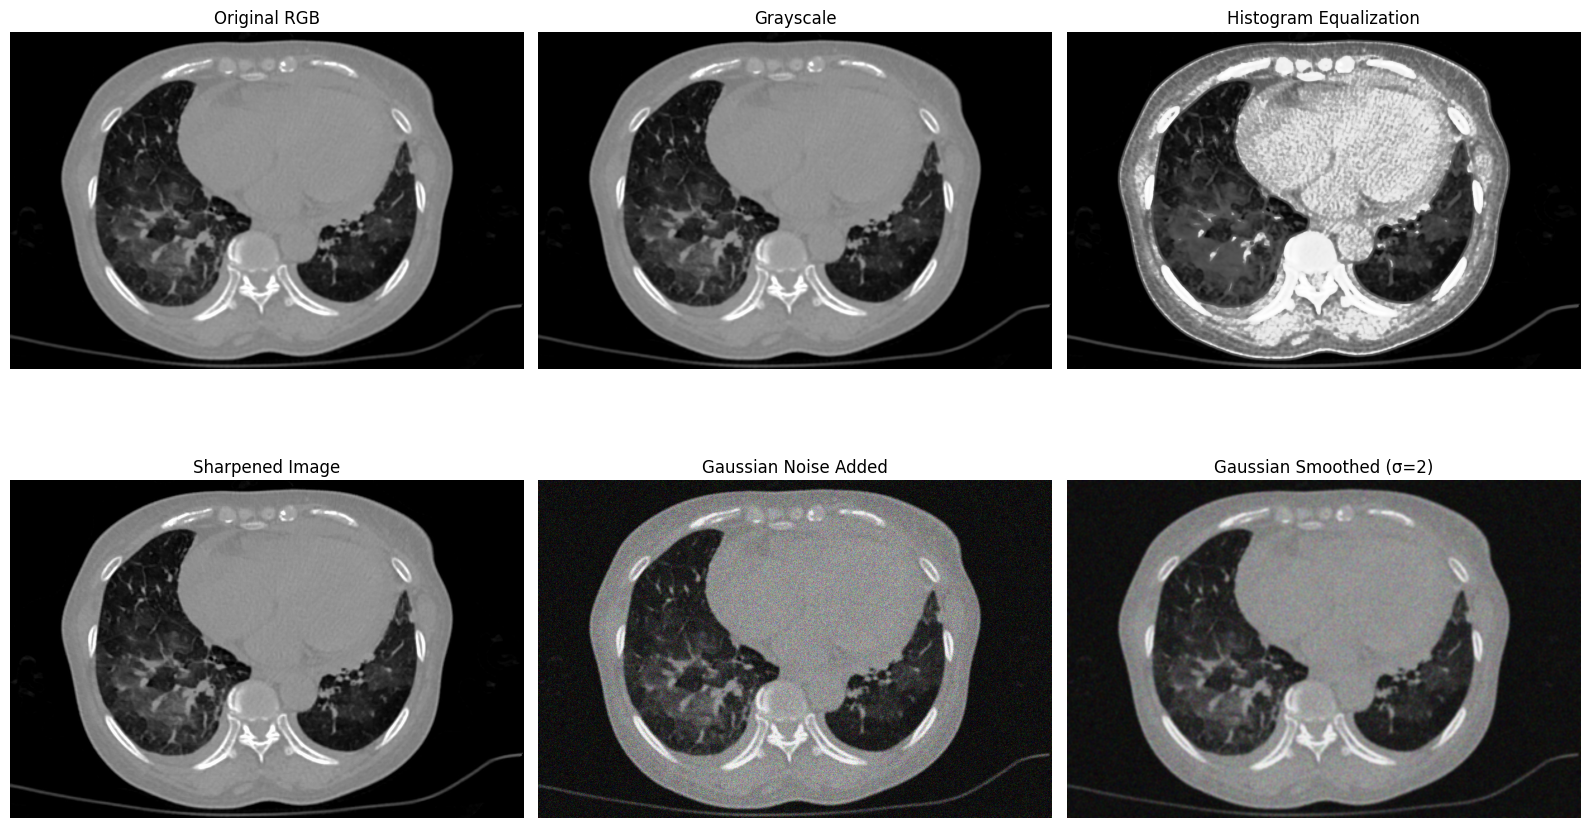

In [4]:
# Plot using classic subplot notation
plt.figure(figsize=(16, 10))

plt.subplot(231)
plt.imshow(image)
plt.title('Original RGB')
plt.axis('off')

plt.subplot(232)
plt.imshow(image_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(233)
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('off')

plt.subplot(234)
plt.imshow(sharpened)
plt.title('Sharpened Image')
plt.axis('off')

plt.subplot(235)
plt.imshow(noise_image)
plt.title('Gaussian Noise Added')
plt.axis('off')

plt.subplot(236)
plt.imshow(smoothed_image)
plt.title(f'Gaussian Smoothed (σ={sigma})')
plt.axis('off')

plt.tight_layout()
plt.show()


Mask shape: (881, 1339)


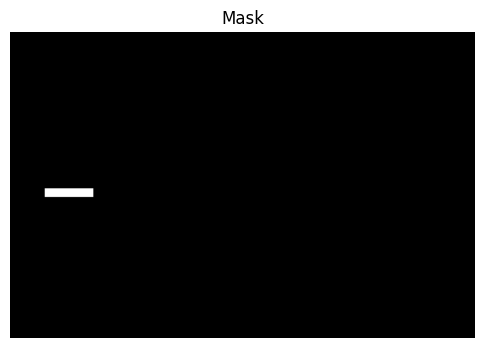

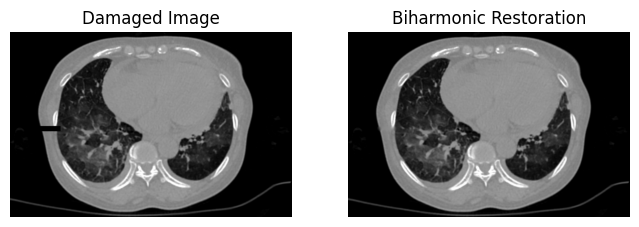

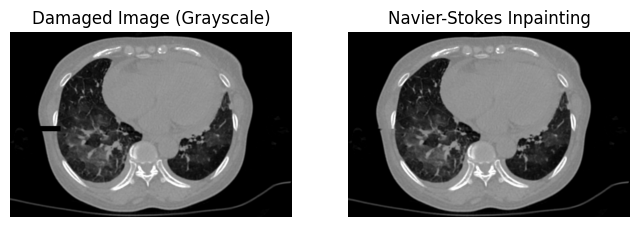

In [ ]:
# 2. Image Restoration
mask = np.zeros(image.shape[:2], dtype=np.uint8)
mask[450:475, 100:240] = 1  # Region to inpaint
print("Mask shape:", mask.shape)

plt.figure(figsize=(6,4))
plt.axis('off')
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.show()

# 2. Create damaged image by setting masked pixels to 0 (black)
damaged_image = image.copy()
damaged_image[mask == 1] = 0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image")
plt.imshow(damaged_image)

# 3. Biharmonic inpainting expects grayscale float image [0,1]
# Convert damaged image to grayscale float [0,1]
damaged_gray = cv2.cvtColor(damaged_image, cv2.COLOR_RGB2GRAY) / 255.0

restored_biharmonic = inpaint.inpaint_biharmonic(damaged_gray, mask)

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Biharmonic Restoration")
plt.imshow(restored_biharmonic, cmap='gray')
plt.show()

# 4. Navier-Stokes inpainting (OpenCV) - input must be uint8 grayscale or color
damaged_gray_uint8 = (damaged_gray * 255).astype(np.uint8)
mask_255 = (mask * 255).astype(np.uint8)

inpainted_ns = cv2.inpaint(damaged_gray_uint8, mask_255, inpaintRadius=3, flags=cv2.INPAINT_NS)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("Damaged Image (Grayscale)")
plt.imshow(damaged_gray, cmap='gray')

plt.subplot(1,2,2)
plt.axis('off')
plt.title("Navier-Stokes Inpainting")
plt.imshow(inpainted_ns, cmap='gray')
plt.show()